<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"]='KGAT_c03d989b55c966d18c971a92b023645b'

In [ ]:
!kaggle datasets download -d britikak/busi-dataset

Dataset URL: https://www.kaggle.com/datasets/britikak/busi-dataset
License(s): unknown
100% 195M/195M [00:01<00:00, 137MB/s]



In [ ]:
!unzip -q busi-dataset.zip -d busi_dataset

In [ ]:
!pip install albumentations matplotlib torchinfo -q

import os
import gc
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import albumentations as A
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "/content/busi_dataset/Dataset_BUSI_with_GT"
CLASSES = ["benign", "malignant"]
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 40

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])


class BUSISegmentationDataset(Dataset):
    def __init__(self, base_dir, classes, transform=None):
        self.samples = []
        self.transform = transform
        for cls in classes:
            cls_dir = os.path.join(base_dir, cls)
            if not os.path.exists(cls_dir): continue
            images = [f for f in os.listdir(cls_dir) if f.endswith(".png") and "mask" not in f]
            for img_name in images:
                img_path = os.path.join(cls_dir, img_name)
                base_name = img_name.replace(".png", "")
                mask_files = [f for f in os.listdir(cls_dir) if f.startswith(base_name + "_mask")]
                if not mask_files: continue
                self.samples.append((img_path, [os.path.join(cls_dir, f) for f in mask_files]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_paths = self.samples[idx]
        image = np.array(Image.open(img_path).convert("RGB"))
        combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        for mpath in mask_paths:
            mask = np.array(Image.open(mpath).convert("L"))
            combined_mask = np.logical_or(combined_mask, (mask > 0).astype(np.uint8))
        combined_mask = combined_mask.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=combined_mask)
            image, combined_mask = augmented["image"], augmented["mask"]

        return torch.from_numpy(image).permute(2, 0, 1).float(), torch.from_numpy(combined_mask).unsqueeze(0).float()

full_dataset = BUSISegmentationDataset(BASE_DIR, classes=CLASSES, transform=None)
indices = list(range(len(full_dataset)))
np.random.shuffle(indices)

train_sz, val_sz = int(0.8 * len(full_dataset)), int(0.1 * len(full_dataset))
train_ds = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, train_transform), indices[val_sz:train_sz + val_sz])
val_ds = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, val_transform), indices[:val_sz])
test_ds = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, val_transform), indices[train_sz + val_sz:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

/tmp/ipykernel_2321/974386163.py:30: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)


# MODEL A: PURE RESNET50 UNET

class PureResNet50UNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.e1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool
        self.e2 = resnet.layer1
        self.e3 = resnet.layer2
        self.e4 = resnet.layer3
        self.bottleneck = resnet.layer4

        self.up4 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024 + 1024, 1024)
        self.up3 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512 + 512, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256 + 256, 256)
        self.up1 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64 + 64, 64)
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec0 = DoubleConv(32, 32)
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        b = self.bottleneck(e4)

        d4 = self.dec4(torch.cat([e4, self.up4(b)], dim=1))
        d3 = self.dec3(torch.cat([e3, self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([e2, self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([e1, self.up1(d2)], dim=1))
        return self.final_conv(self.dec0(self.up0(d1)))

#  WAVELET (DB1) RESNET50 UNET

class Db1_2DWT(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        h0 = torch.tensor([0.70710678, 0.70710678])
        h1 = torch.tensor([-0.70710678, 0.70710678])
        ll = torch.outer(h0, h0); lh = torch.outer(h0, h1)
        hl = torch.outer(h1, h0); hh = torch.outer(h1, h1)
        filters = torch.stack([ll, lh, hl, hh], dim=0).unsqueeze(1).repeat(in_channels, 1, 1, 1)
        self.register_buffer('filters', filters)
        self.in_channels = in_channels

    def forward(self, x):
        return F.conv2d(x, self.filters, stride=2, padding=0, groups=self.in_channels)

class WaveletResNet50UNet_DB1(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.r_e1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.r_pool = resnet.maxpool
        self.r_e2 = resnet.layer1
        self.r_e3 = resnet.layer2
        self.r_e4 = resnet.layer3
        self.r_bottleneck = resnet.layer4

        self.w_dwt1 = Db1_2DWT(in_channels=3)
        self.w_conv1 = DoubleConv(3 * 4, 64)
        self.w_dwt2 = Db1_2DWT(in_channels=64)
        self.w_conv2 = DoubleConv(64 * 4, 256)
        self.w_dwt3 = Db1_2DWT(in_channels=256)
        self.w_conv3 = DoubleConv(256 * 4, 512)
        self.w_dwt4 = Db1_2DWT(in_channels=512)
        self.w_conv4 = DoubleConv(512 * 4, 1024)
        self.w_dwt_b = Db1_2DWT(in_channels=1024)
        self.w_conv_b = DoubleConv(1024 * 4, 2048)

        self.up4 = nn.ConvTranspose2d(4096, 1024, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(2048 + 1024, 1024)
        self.up3 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(1024 + 512, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(512 + 256, 256)
        self.up1 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128 + 64, 64)
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec0 = DoubleConv(32, 32)
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        re1 = self.r_e1(x)
        we1 = self.w_conv1(self.w_dwt1(x))
        s1 = torch.cat([re1, we1], dim=1)

        re2 = self.r_e2(self.r_pool(re1))
        we2 = self.w_conv2(self.w_dwt2(we1))
        s2 = torch.cat([re2, we2], dim=1)

        re3 = self.r_e3(re2)
        we3 = self.w_conv3(self.w_dwt3(we2))
        s3 = torch.cat([re3, we3], dim=1)

        re4 = self.r_e4(re3)
        we4 = self.w_conv4(self.w_dwt4(we3))
        s4 = torch.cat([re4, we4], dim=1)

        rb = self.r_bottleneck(re4)
        wb = self.w_conv_b(self.w_dwt_b(we4))
        b = torch.cat([rb, wb], dim=1)

        d4 = self.dec4(torch.cat([s4, self.up4(b)], dim=1))
        d3 = self.dec3(torch.cat([s3, self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([s2, self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([s1, self.up1(d2)], dim=1))
        return self.final_conv(self.dec0(self.up0(d1)))

In [ ]:

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_loss = (self.alpha * (1 - pt) ** self.gamma * bce_loss).mean()

        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1.0 - dice_score

        return 0.5 * focal_loss + 0.5 * dice_loss

def strict_dice_coef(y_true, logits, smooth=1e-5):
    y_pred = (torch.sigmoid(logits) > 0.5).float().view(-1)
    y_true_f = y_true.view(-1)
    inter = (y_true_f * y_pred).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred.sum() + smooth)


def run_ablation_training(model, model_name, epochs=EPOCHS):
    print(f"\n STARTING TRAINING: {model_name}")

    criterion = FocalDiceLoss(alpha=0.25, gamma=2.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_dice': [], 'test_loss': 0.0, 'test_dice': 0.0}
    best_val_dice = 0.0
    best_weights = None
    best_epoch = 0

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        t_loss = t_dice = 0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [{model_name}]", leave=False):
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            t_loss += loss.item()
            with torch.no_grad():
                t_dice += strict_dice_coef(masks, logits).item()

        scheduler.step()


        model.eval()
        v_loss = v_dice = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                logits = model(images)
                loss = criterion(logits, masks)

                v_loss += loss.item()
                v_dice += strict_dice_coef(masks, logits).item()

        avg_t_loss = t_loss / len(train_loader)
        avg_t_dice = t_dice / len(train_loader)
        avg_v_loss = v_loss / len(val_loader)
        avg_v_dice = v_dice / len(val_loader)

        history['train_loss'].append(avg_t_loss)
        history['val_dice'].append(avg_v_dice)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | T-Loss: {avg_t_loss:.4f} | T-Dice: {avg_t_dice:.4f} | V-Loss: {avg_v_loss:.4f} | V-Dice: {avg_v_dice:.4f}")

        if avg_v_dice > best_val_dice:
            best_val_dice = avg_v_dice
            best_epoch = epoch + 1
            best_weights = {k: v.cpu() for k, v in model.state_dict().items()}
            print(f" Best weights saved at Epoch {best_epoch} (Val Dice: {best_val_dice:.4f})")



    print(f" Loading Weights from Epoch {best_epoch} for Test Set...")
    model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
    model.eval()

    test_loss = test_dice = 0
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, masks)

            test_loss += loss.item()
            test_dice += strict_dice_coef(masks, logits).item()

    history['test_loss'] = test_loss / len(test_loader)
    history['test_dice'] = test_dice / len(test_loader)

    print(f" FINAL TEST LOSS ({model_name}): {history['test_loss']:.4f}")
    print(f" FINAL TEST DICE ({model_name}): {history['test_dice']:.4f}")


    return history

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]



 STARTING TRAINING: Model A: Pure ResNet50


Epoch [01/40] | T-Loss: 0.3855 | T-Dice: 0.4722 | V-Loss: 0.3510 | V-Dice: 0.6560
 Best weights saved at Epoch 1 (Val Dice: 0.6560)


Epoch [02/40] | T-Loss: 0.3497 | T-Dice: 0.5541 | V-Loss: 0.3327 | V-Dice: 0.5896


...

Epoch [36/40] | T-Loss: 0.0892 | T-Dice: 0.8623 | V-Loss: 0.1075 | V-Dice: 0.8348


Epoch [37/40] | T-Loss: 0.0905 | T-Dice: 0.8587 | V-Loss: 0.1057 | V-Dice: 0.8378
 Best weights saved at Epoch 37 (Val Dice: 0.8378)


Epoch [38/40] | T-Loss: 0.0864 | T-Dice: 0.8670 | V-Loss: 0.1086 | V-Dice: 0.8329


Epoch [39/40] | T-Loss: 0.0920 | T-Dice: 0.8572 | V-Loss: 0.1086 | V-Dice: 0.8320


Epoch [40/40] | T-Loss: 0.0881 | T-Dice: 0.8628 | V-Loss: 0.1086 | V-Dice: 0.8345
 Loading Weights from Epoch 37 for Test Set...
 FINAL TEST LOSS (Model B: Wavelet db1 + ResNet50): 0.1391
 FINAL TEST DICE (Model B: Wavelet db1 + ResNet50): 0.7738


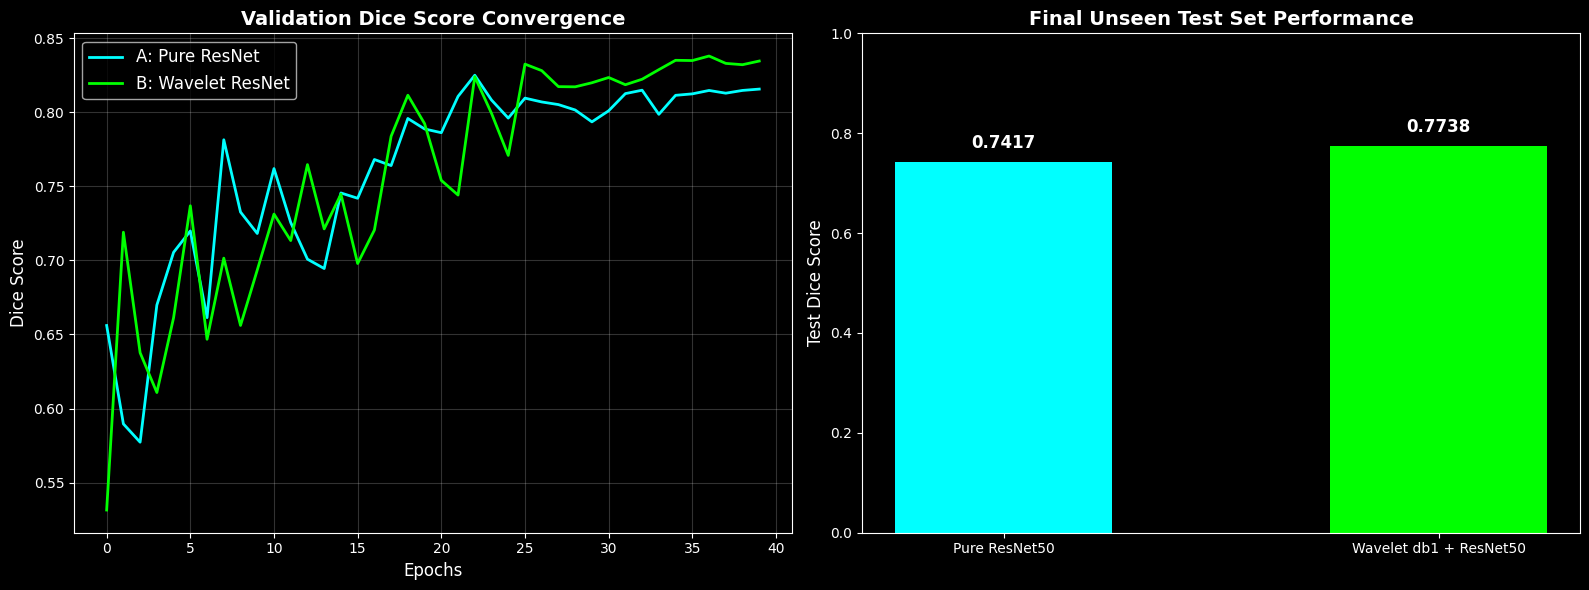

In [ ]:

model_a = PureResNet50UNet(out_channels=1).to(device)
history_a = run_ablation_training(model_a, "Model A: Pure ResNet50", epochs=EPOCHS)

del model_a
torch.cuda.empty_cache()
gc.collect()

model_b = WaveletResNet50UNet_DB1(out_channels=1).to(device)
history_b = run_ablation_training(model_b, "Model B: Wavelet db1 + ResNet50", epochs=EPOCHS)

# Free VRAM immediately
del model_b
torch.cuda.empty_cache()
gc.collect()


plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Validation Dice Curve
axes[0].plot(history_a['val_dice'], label='A: Pure ResNet', color='cyan', linewidth=2)
axes[0].plot(history_b['val_dice'], label='B: Wavelet ResNet', color='lime', linewidth=2)
axes[0].set_title('Validation Dice Score Convergence', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Dice Score', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.2)

labels = ['Pure ResNet50', 'Wavelet db1 + ResNet50']
scores = [history_a['test_dice'], history_b['test_dice']]
colors = ['cyan', 'lime']

bars = axes[1].bar(labels, scores, color=colors, width=0.5)
axes[1].set_title('Final Unseen Test Set Performance', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Test Dice Score', fontsize=12)
axes[1].set_ylim([0, 1.0])

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()